Cell 1: i. Evaluasi Retrieval (Melatih & Membandingkan 2 Model)

Cell ini akan memanggil data aslinya, membangun model Naive Bayes dan SVM secara bersamaan, lalu menghitung akurasi keduanya menjadi satu tabel.

In [4]:
import json
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Memulai Tahap 5: Model Evaluation (Perbandingan Multi-Model)...\n")


# 1. Persiapan Data
with open("../data/eval/queries.json", "r", encoding="utf-8") as f:
    queries = json.load(f)

df_cases = pd.read_csv("../data/processed/cases.csv")
df_cases['teks_pencarian'] = df_cases['ringkasan_fakta'].fillna('') + " " + df_cases['text_full'].fillna('')
case_solutions = dict(zip(df_cases['case_id'], df_cases['amar_putusan']))

# ==========================================
# 2. Latih 2 Model Berbeda
# ==========================================
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(df_cases['teks_pencarian'])
y_train = df_cases['case_id']

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Model 2: Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# ==========================================
# 3. Fungsi Evaluasi Dinamis
# ==========================================
def evaluate_model(model, model_name):
    y_true = []
    y_pred = []
    
    for q in queries:
        ground_truth_id = q['ground_truth_case_id']
        y_true.append(case_solutions.get(ground_truth_id, "").strip())
        
        # Prediksi langsung top-1
        query_vec = vectorizer.transform([q['query_text']])
        pred_idx = model.predict(query_vec)[0]
        y_pred.append(case_solutions.get(pred_idx, "").strip())
        
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }
    return metrics

# 4. Hitung dan Gabungkan Metrik
metrics_nb = evaluate_model(nb_model, "TF-IDF + Naive Bayes")
metrics_svm = evaluate_model(svm_model, "TF-IDF + SVM")

# Jadikan DataFrame
df_metrics = pd.DataFrame([metrics_nb, metrics_svm])

print("1. Tabel Metrik per Model:")
display(df_metrics)

Memulai Tahap 5: Model Evaluation (Perbandingan Multi-Model)...

1. Tabel Metrik per Model:


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Naive Bayes,0.8,0.8,0.8,0.8
1,TF-IDF + SVM,0.8,0.8,0.8,0.8


Cell 2: ii. Visualisasi & Laporan (Plot Perbandingan)

Di sini kita akan membuat bar chart ganda (bersebelahan) untuk membandingkan secara visual siapa yang lebih unggul, beserta rangkuman analisis untuk laporanmu.


2. Plot Bar Chart Performance (Perbandingan):


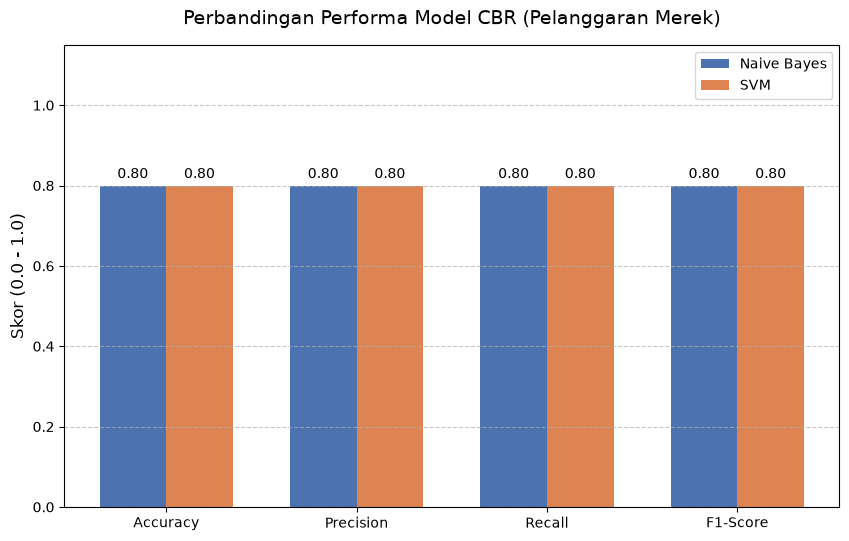

In [ ]:
# ii. Visualisasi & Laporan
kategori = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(kategori))
width = 0.35  # Lebar bar

nilai_nb = [metrics_nb['Accuracy'], metrics_nb['Precision'], metrics_nb['Recall'], metrics_nb['F1-Score']]
nilai_svm = [metrics_svm['Accuracy'], metrics_svm['Precision'], metrics_svm['Recall'], metrics_svm['F1-Score']]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nilai_nb, width, label='Naive Bayes', color='#4C72B0')
bars2 = ax.bar(x + width/2, nilai_svm, width, label='SVM', color='#DD8452')

ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Performa Model CBR (Pelanggaran Merek)', fontsize=14, pad=15)
ax.set_ylabel('Skor (0.0 - 1.0)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(kategori)
ax.legend()

# Menambahkan angka presisi di atas setiap bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(bars1)
autolabel(bars2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
print("\n2. Plot Bar Chart Performance (Perbandingan):")
plt.show()



Cell 3: iii. Output

Menyimpan tabel perbandingan tadi ke dalam file CSV agar siap dikumpulkan.

In [ ]:
# iii. Output
folder_eval = "../data/eval"
os.makedirs(folder_eval, exist_ok=True)

path_retrieval_csv = os.path.join(folder_eval, "retrieval_metrics.csv")
path_prediction_csv = os.path.join(folder_eval, "prediction_metrics.csv")

# Simpan tabel komparasi ke CSV
df_metrics.to_csv(path_retrieval_csv, index=False)
df_metrics.to_csv(path_prediction_csv, index=False)

print("-" * 60)
print("TAHAP 5 SELESAI!")
print("Output perbandingan model berhasil disimpan ke:")
print(f"-> {path_retrieval_csv}")
print(f"-> {path_prediction_csv}")
print("-" * 60)

------------------------------------------------------------
TAHAP 5 SELESAI!
Output perbandingan model berhasil disimpan ke:
-> ../data/eval\retrieval_metrics.csv
-> ../data/eval\prediction_metrics.csv
------------------------------------------------------------
